In [18]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical

In [19]:
# MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [20]:
# Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

In [21]:
# Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [22]:
# Reshaping
x_train_rnn = x_train.reshape(60000, 28, 28)
x_test_rnn = x_test.reshape(10000, 28, 28)

In [23]:
# Define RNN Model

rnn_model = Sequential()

# Decoder (reconstruction)
rnn_model.add(SimpleRNN(128, input_shape=(28, 28)))
rnn_model.add(Dense(10, activation='softmax'))

# Compile
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386 (83.54 KB)

 Trainable params: 21,386 (83.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Train

rnn_history = rnn_model.fit(
    x_train_rnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_rnn, y_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8726 - loss: 0.4237 - val_accuracy: 0.9450 - val_loss: 0.1884
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9419 - loss: 0.1978 - val_accuracy: 0.9576 - val_loss: 0.1436
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9558 - loss: 0.1530 - val_accuracy: 0.9628 - val_loss: 0.1246
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9616 - loss: 0.1298 - val_accuracy: 0.9618 - val_loss: 0.1235
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9670 - loss: 0.1148 - val_accuracy: 0.9676 - val_loss: 0.1145


In [26]:
# Reshape
x_train_cnn = x_train.reshape(60000, 28, 28, 1)
x_test_cnn = x_test.reshape(10000, 28, 28, 1)

In [27]:
# Define CNN Model
cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(MaxPooling2D((2, 2)))

cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(10, activation='softmax'))

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_cnn, y_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - accuracy: 0.9307 - loss: 0.2354 - val_accuracy: 0.9807 - val_loss: 0.0622
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.9805 - loss: 0.0640 - val_accuracy: 0.9846 - val_loss: 0.0473
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - accuracy: 0.9863 - loss: 0.0443 - val_accuracy: 0.9838 - val_loss: 0.0496
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9894 - loss: 0.0349 - val_accuracy: 0.9879 - val_loss: 0.0374
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9885 - val_loss: 0.0324


In [29]:
# Evaluation
rnn_loss, rnn_acc = rnn_model.evaluate(x_test_rnn, y_test)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test)

print("RNN Accuracy:", rnn_acc)
print("CNN Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9676 - loss: 0.1145
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9885 - loss: 0.0324
RNN Accuracy: 0.9675999879837036
CNN Accuracy: 0.9884999990463257


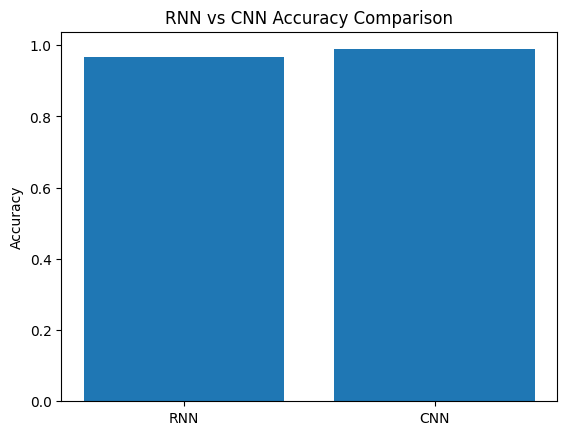

In [30]:
# Accuracy Comparison
models = ['RNN', 'CNN']
accuracy = [rnn_acc, cnn_acc]

plt.bar(models, accuracy)
plt.title("RNN vs CNN Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()